In [1]:
import numpy as np
import pandas as pd
import sys

from astropy.coordinates import Galactic, ICRS
from astropy import units as u
from modules.vr_opt import VrOpt

import nbimporter
import visualisations
import consensus_clusterings

sys.path.append('/Users/lui/Documents/3_semestr/Project/code/local-clustering/SemiMetricClustering')
from SemiMetricDensity import SemiMetricDensity

import shell_grid

In [2]:
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'tab:grey']
zorders = [2, 2, 2, 2, 2, 1]
alphas = [0.9, 0.9, 0.9, 0.9, 0.9, 0.3]
log = True

# Create 6D Gaussian data
np.random.seed(42) 
n = 500# 1000
X_bg = (np.random.rand(n*5, 6) - 0.5) * 50 #background dataset of random points uniformly distributed 6D

mu = np.array([-5, 5, 5, 5, -5, 5]) #first 3 for average position of the Cluster in 3D(XYZ). Last 3 for average velocities in (VxVyVz)
c_xx = c_yy = 20 #Variance of the average in x and y.
c_xy = 15 # correlation of x and y, positive -> there is a correlation 
c_zz = 3 #Variance in z 
c_uvw = 1
cov = np.diag([c_xx, c_yy, c_zz, c_uvw, c_uvw, c_uvw])
# Put in nonzero covariances in X-Y space
cov[0, 1] = cov[1, 0] = c_xy #makes positive correlation of x and y
# Add signal
X_sig_1 = np.random.multivariate_normal(mu, cov, n//2) #generate n/2 data points based on mu and cov

# Second cluster
mu_2 = np.array([5, -5, -5, -5, 5, -5])
c_xx_2 = c_yy = 20
c_xy_2 = -15
c_zz_2 = 3
cov = np.diag([c_xx_2, c_yy, c_zz_2, c_uvw, c_uvw, c_uvw])
# Put in nonzero covariances in X-Y space
cov[0, 1] = cov[1, 0] = c_xy_2
X_sig_2 = np.random.multivariate_normal(mu_2, cov, n//2)

# Additional clusters' parameters
# Cluster 3
mu_3 = np.array([10, -10, -10, -10, 10, -10])
c_xx_3 = c_yy_3 = 25 # More spread in X-Y plane
c_xy_3 = 10
c_zz_3 = 4
cov_3 = np.diag([c_xx_3, c_yy_3, c_zz_3, c_uvw, c_uvw, c_uvw])
cov_3[0, 1] = cov_3[1, 0] = c_xy_3
X_sig_3 = np.random.multivariate_normal(mu_3, cov_3, n//2)

# Cluster 4
mu_4 = np.array([-7, -7, -7, -7, -7, -7])
c_xx_4 = c_yy_4 = 30
c_xy_4 = -12
c_zz_4 = 5
cov_4 = np.diag([c_xx_4, c_yy_4, c_zz_4, c_uvw, c_uvw, c_uvw])
cov_4[0, 1] = cov_4[1, 0] = c_xy_4
X_sig_4 = np.random.multivariate_normal(mu_4, cov_4, n//2)

# Cluster 5
mu_5 = np.array([2, -2, -2, 2, 2, 2])
c_xx_5 = c_yy_5 = 35
c_xy_5 = 8
c_zz_5 = 6
cov_5 = np.diag([c_xx_5, c_yy_5, c_zz_5, c_uvw, c_uvw, c_uvw])
cov_5[0, 1] = cov_5[1, 0] = c_xy_5
X_sig_5 = np.random.multivariate_normal(mu_5, cov_5, n//2)

X = np.concatenate([X_bg, X_sig_1, X_sig_2, X_sig_3, X_sig_4, X_sig_5], axis=0) #5000 bg stars, and 5*500 cluster stars
labels = np.concatenate([np.zeros(n*5), np.ones(n//2), np.ones(n//2)*2, np.ones(n//2)*3, np.ones(n//2)*4, np.ones(n//2)*5])

df = pd.DataFrame(X, columns=['x', 'y', 'z', 'vx', 'vy', 'vz'])
# Transform to spherical coordinates
gal_coords = Galactic(
    u=df.x.values * u.pc,
    v=df.y.values * u.pc,
    w=df.z.values * u.pc,
    # velocities UVW
    U=df.vx.values * u.km / u.s,
    V=df.vy.values * u.km / u.s,
    W=df.vz.values * u.km / u.s,
    representation_type="cartesian",
    # Velocity representation
    differential_type="cartesian",
)
# transform to ICRS
icrs_coords = gal_coords.transform_to(ICRS())
icrs_coords.representation_type = "spherical"

ra = icrs_coords.ra.value
dec = icrs_coords.dec.value
dist = icrs_coords.distance.value
pmra = icrs_coords.pm_ra.value * np.cos(np.deg2rad(dec))
pmdec = icrs_coords.pm_dec.value
rv_calc = icrs_coords.radial_velocity.value

df['ra'] = ra
df['dec'] = dec
df['dist'] = dist
df['pmra'] = pmra
df['pmdec'] = pmdec
df['radial_velocity'] = rv_calc

df['vt_ra'] = df.pmra * df.dist * 4.74
df['vt_dec'] = df.pmdec * df.dist * 4.74

idx_cluster_1 = np.where(labels==1)[0]
idx_cluster_2 = np.where(labels==2)[0]
idx_cluster_3 = np.where(labels==3)[0]
idx_cluster_4 = np.where(labels==4)[0]
idx_cluster_5 = np.where(labels==5)[0]
idx_bg = np.where(labels==0)[0]

In [3]:
# Remove background
df_filtered, labels_filtered, _ = shell_grid.remove_background_noise(df, labels, ['x', 'y', 'z', 'vx', 'vy', 'vz'], k=10, detected_labels=None, print_info = True)

Initial dataset label distribution:
0.0    2500
1.0     250
2.0     250
3.0     250
4.0     250
5.0     250
Name: count, dtype: int64
Filtered dataset label distribution:
1.0    250
2.0    250
3.0    250
4.0    250
5.0    250
0.0     27
Name: count, dtype: int64
Total points before filtering: 3750, after filtering: 1277
Removed 2473 background points.


In [4]:
K = 9  
consensus_labels = shell_grid.run_shell_grid_consensus_clustering(
    df, K, labels, solver='cspa', consensus_nclass=K, random_state=42, colors=colors, alphas=alphas,
    zorders=zorders, num_rotations=3, rotation_axis='z', rotation_angle=None,
    num_shifts=3, num_sectors=3, num_shells=3, projection='xy', max_iter=1_000,
    method="random", theta=0.001, epsilon=0.0001,initial_partition=None, rho_multiplier=None,
    verbose=False, th_dist=5, dist_max=1e3, print_info=False, entire_G=False)

In [5]:
overall_nmi = consensus_clusterings.calculate_nmi_and_purity(consensus_labels, labels, background_label=0)

Overall NMI (ignoring background points): 0.6852

Cluster 0:
  - Number of points: 404
  - Purity (excluding background): 0.7080
  - True label distribution in this cluster:
    * Background noise: 154 points
    * True label 1.0: 2 points
    * True label 4.0: 71 points
    * True label 5.0: 177 points


Cluster 1:
  - Number of points: 404
  - Purity (excluding background): 0.8519
  - True label distribution in this cluster:
    * Background noise: 215 points
    * True label 1.0: 6 points
    * True label 2.0: 4 points
    * True label 4.0: 161 points
    * True label 5.0: 18 points


Cluster 2:
  - Number of points: 429
  - Purity (excluding background): 0.6909
  - True label distribution in this cluster:
    * Background noise: 264 points
    * True label 1.0: 114 points
    * True label 4.0: 11 points
    * True label 5.0: 40 points


Cluster 3:
  - Number of points: 404
  - Purity (excluding background): 0.8889
  - True label distribution in this cluster:
    * Background noise:

In [6]:
nmi = consensus_clusterings.calculate_nmi(consensus_labels, labels, background_label=0)
nmi

0.6851765629731946

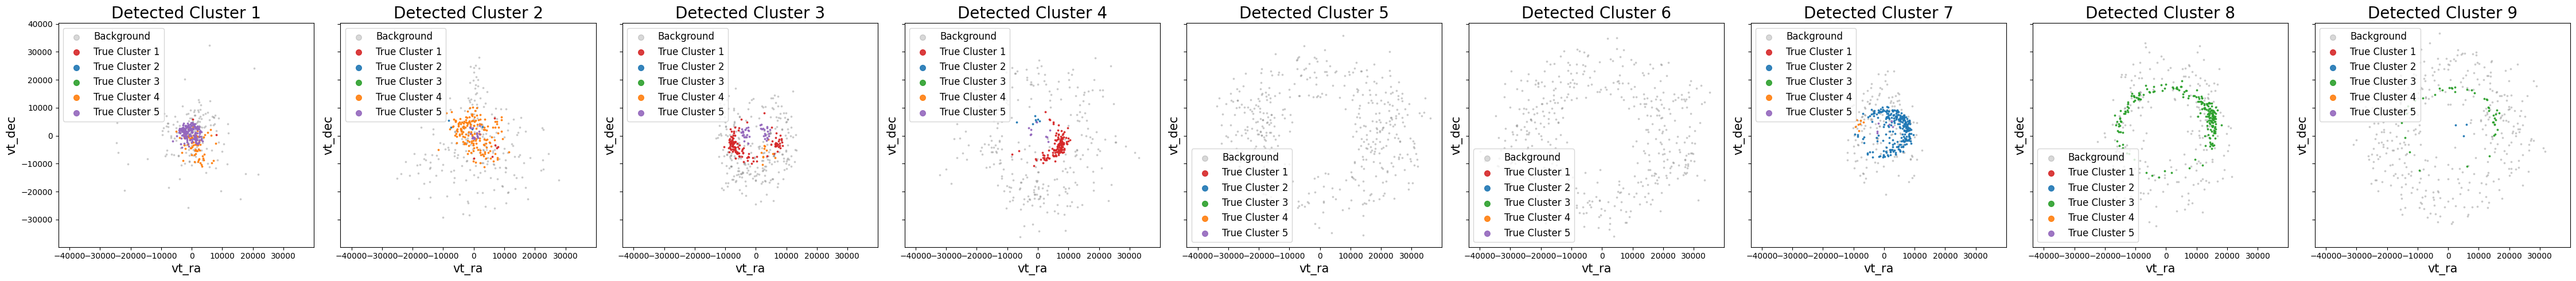

In [7]:
visualisations.visualise_cluster_result(
    df=df,
    cluster_labels=consensus_labels,
    true_labels=labels,
    K=len(np.unique(consensus_labels)),  
    x_col='vt_ra',
    y_col='vt_dec',
    colors=colors,  
    alphas=alphas,  
    zorders=zorders  
)

In [8]:
# Rerun shell grid and consensus clustering on specific detected cluster after previous run of the algorithm 
detected_cluster_id = 0
K = 5

clustering_results, subset_df, subset_true_labels, clustering_time = shell_grid.rerun_shell_grid_clustering_on_detected_cluster(
    df, labels, detected_cluster_id, consensus_labels, 
    K = K, solver = 'hbgf', consensus_nclass = K, num_rotations = 3, num_shifts = 3, 
    num_sectors = 3, num_shells = 3, projection='xy', colors=colors, 
    alphas=alphas, zorders=zorders, rotation_axis='z', 
    rotation_angle=30, max_iter=1000, method="random", 
    theta=0.001, epsilon=0.0001, th_dist=5, dist_max=1000, 
    print_info=False, entire_G=False)

In [9]:
overall_nmi = consensus_clusterings.calculate_nmi_and_purity(clustering_results, subset_true_labels, background_label=0)

Overall NMI (ignoring background points): 0.2085

Cluster 0:
  - Number of points: 73
  - Purity (excluding background): 0.6774
  - True label distribution in this cluster:
    * Background noise: 42 points
    * True label 1.0: 1 points
    * True label 4.0: 9 points
    * True label 5.0: 21 points


Cluster 1:
  - Number of points: 84
  - Purity (excluding background): 0.7609
  - True label distribution in this cluster:
    * Background noise: 38 points
    * True label 4.0: 35 points
    * True label 5.0: 11 points


Cluster 2:
  - Number of points: 63
  - Purity (excluding background): 0.5714
  - True label distribution in this cluster:
    * Background noise: 56 points
    * True label 1.0: 1 points
    * True label 4.0: 2 points
    * True label 5.0: 4 points


Cluster 3:
  - Number of points: 92
  - Purity (excluding background): 0.7126
  - True label distribution in this cluster:
    * Background noise: 5 points
    * True label 4.0: 25 points
    * True label 5.0: 62 points




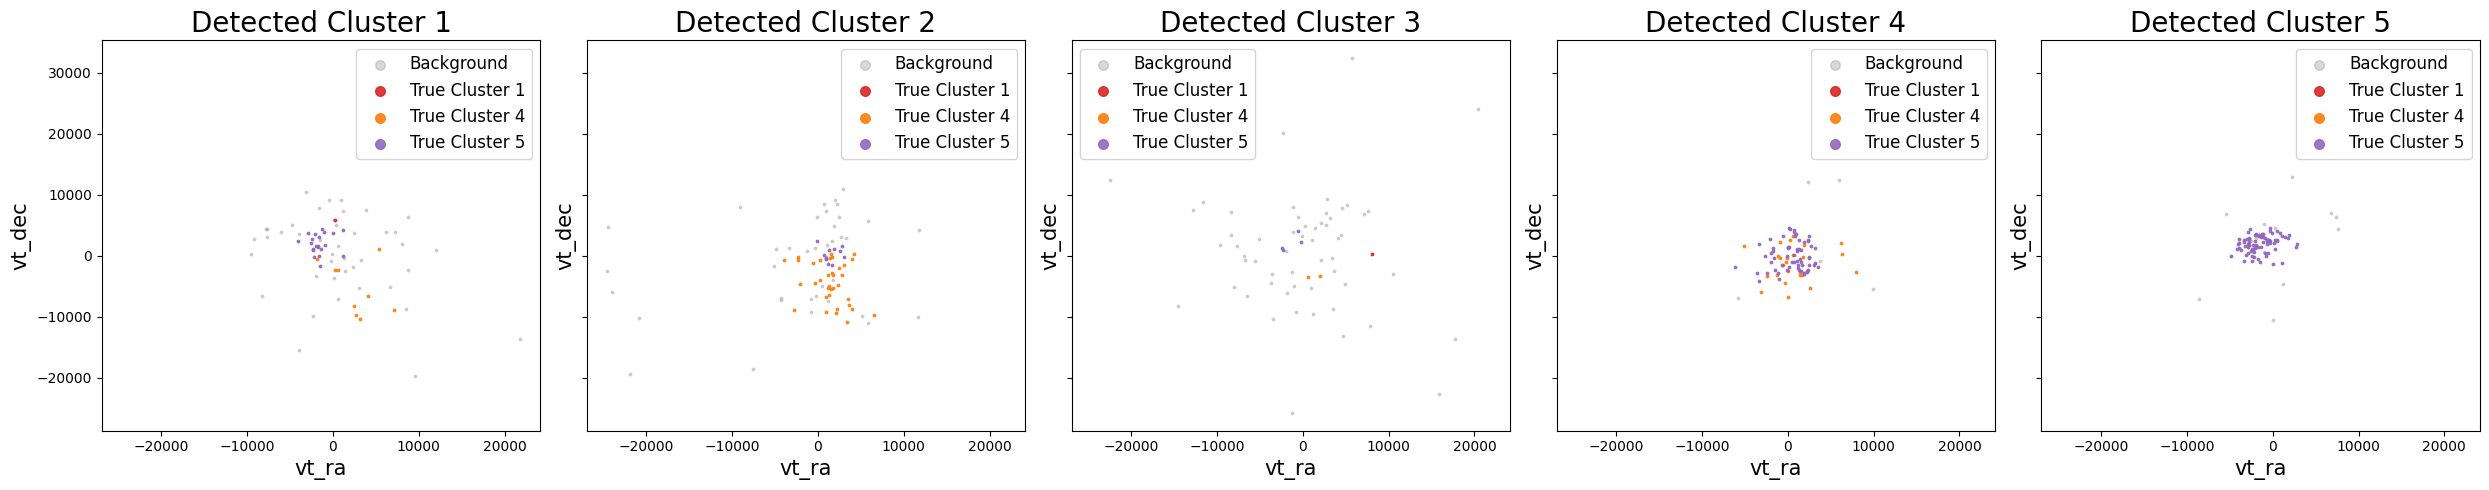

In [10]:
visualisations.visualise_cluster_result(
    df=subset_df,
    cluster_labels=clustering_results,
    true_labels=subset_true_labels,
    K=len(np.unique(clustering_results)),  
    x_col='vt_ra',
    y_col='vt_dec',
    colors=colors,  
    alphas=alphas,  
    zorders=zorders  
)

In [11]:
# Try different parameters combinations, save result to csv file; for filtered data from background points
K_values = [9]  
num_rotations_values = [2, 4]
num_shifts_values = [2]
num_shells_values = [2, 4]
num_sectors_values = [3]
rotation_angles = [30]
solvers = ['cspa', 'hgpa', 'mcla', 'hbgf', 'nmf']
consensus_nclass_values = [9, 6]
theta_values = [0.01, 0.001]
epsilon_values = [0.001, 0.0001]
th_dist_values = [5, 15, 25, 45, None]
dist_max_values = [1000]

In [12]:
results_df_filtered = shell_grid.experiment_shell_grid_clustering(df_filtered, labels_filtered, 
                                     K_values, num_rotations_values, num_shifts_values, 
                                     num_shells_values, num_sectors_values, rotation_angles, 
                                     solvers, consensus_nclass_values, theta_values, 
                                     epsilon_values, th_dist_values, dist_max_values, 
                                     projection='xy', colors=colors, alphas=alphas, 
                                     zorders=zorders, output_file='clustering_results_df_filtered.csv')

Results saved to clustering_results_df_filtered.csv


,K,Num Rotations,Num Shifts,Num Shells,Num Sectors,Rotation Angle,Solver,Consensus NClass,Theta,Epsilon,Th_dist,Dist_max,NMI,Runtime
0,9,2,2,2,3,30,cspa,9,0.010,0.0010,5.0,1000,0.505376,5.716920
1,9,2,2,2,3,30,cspa,9,0.010,0.0010,15.0,1000,0.307205,6.331250
2,9,2,2,2,3,30,cspa,9,0.010,0.0010,25.0,1000,0.342273,6.479567
3,9,2,2,2,3,30,cspa,9,0.010,0.0010,45.0,1000,0.346005,5.610921
4,9,2,2,2,3,30,cspa,9,0.010,0.0010,NaN,1000,0.381640,6.094241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,9,4,2,4,3,30,nmf,6,0.001,0.0001,5.0,1000,0.601194,5.862499
796,9,4,2,4,3,30,nmf,6,0.001,0.0001,15.0,1000,0.271080,5.984789
797,9,4,2,4,3,30,nmf,6,0.001,0.0001,25.0,1000,0.002783,5.451636
798,9,4,2,4,3,30,nmf,6,0.001,0.0001,45.0,1000,0.331380,5.735310


In [15]:
best_options_filtered, worst_options_filtered = shell_grid.get_best_and_worst_options("clustering_results_df_filtered_shellgrid.csv", top_n=10)

In [16]:
print("Top 10 best configurations:")
best_options_filtered

Top 10 best configurations:


,K,Num Rotations,Num Shifts,Num Shells,Num Sectors,Rotation Angle,Solver,Consensus NClass,Theta,Epsilon,Th_dist,Dist_max,NMI,Runtime
185,9,2,2,2,3,30,nmf,6,0.010,0.0001,5.0,1000,0.680292,3.425940
585,9,4,2,2,3,30,nmf,6,0.010,0.0001,5.0,1000,0.642401,6.803936
785,9,4,2,4,3,30,nmf,6,0.010,0.0001,5.0,1000,0.633527,5.856054
560,9,4,2,2,3,30,nmf,9,0.010,0.0010,5.0,1000,0.631959,7.900256
590,9,4,2,2,3,30,nmf,6,0.001,0.0010,5.0,1000,0.629411,6.538389
580,9,4,2,2,3,30,nmf,6,0.010,0.0010,5.0,1000,0.629262,7.413596
790,9,4,2,4,3,30,nmf,6,0.001,0.0010,5.0,1000,0.614603,5.325401
180,9,2,2,2,3,30,nmf,6,0.010,0.0010,5.0,1000,0.612334,3.450945
780,9,4,2,4,3,30,nmf,6,0.010,0.0010,5.0,1000,0.607757,5.717130
795,9,4,2,4,3,30,nmf,6,0.001,0.0001,5.0,1000,0.601194,5.862499


In [17]:
print("Top 10 worst configurations:")
worst_options_filtered

Top 10 worst configurations:


,K,Num Rotations,Num Shifts,Num Shells,Num Sectors,Rotation Angle,Solver,Consensus NClass,Theta,Epsilon,Th_dist,Dist_max,NMI,Runtime
797,9,4,2,4,3,30,nmf,6,0.001,0.0001,25.0,1000,0.002783,5.451636
397,9,2,2,4,3,30,nmf,6,0.001,0.0001,25.0,1000,0.003184,2.921323
777,9,4,2,4,3,30,nmf,9,0.001,0.0001,25.0,1000,0.004552,6.131425
377,9,2,2,4,3,30,nmf,9,0.001,0.0001,25.0,1000,0.008232,2.922606
637,9,4,2,4,3,30,cspa,6,0.001,0.0001,25.0,1000,0.011413,9.942657
617,9,4,2,4,3,30,cspa,9,0.001,0.0001,25.0,1000,0.012173,9.933255
297,9,2,2,4,3,30,mcla,9,0.001,0.0001,25.0,1000,0.016870,3.522811
197,9,2,2,2,3,30,nmf,6,0.001,0.0001,25.0,1000,0.022480,2.922553
454,9,4,2,2,3,30,hgpa,9,0.001,0.0010,NaN,1000,0.031483,4.471976
196,9,2,2,2,3,30,nmf,6,0.001,0.0001,15.0,1000,0.031942,2.919347


In [11]:
# Try different parameters combinations, save result to csv file; for unfiltered data from background points
K_values = [9]  
num_rotations_values = [2, 4]
num_shifts_values = [2]
num_shells_values = [2, 4]
num_sectors_values = [3]
rotation_angles = [30]
solvers = ['cspa', 'mcla', 'hbgf', 'nmf']
consensus_nclass_values = [9, 6]
theta_values = [0.01]
epsilon_values = [0.001]
th_dist_values = [2, 5, 15]
dist_max_values = [1000]

In [12]:
results_df_nonfiltered = shell_grid.experiment_shell_grid_clustering(df, labels, 
                                     K_values, num_rotations_values, num_shifts_values, 
                                     num_shells_values, num_sectors_values, rotation_angles, 
                                     solvers, consensus_nclass_values, theta_values, 
                                     epsilon_values, th_dist_values, dist_max_values, 
                                     projection='xy', colors=colors, alphas=alphas, 
                                     zorders=zorders, output_file='clustering_results_df_nonfiltered.csv')

Running Experiments: 100%|██████████| 96/96 [1:26:40<00:00, 54.17s/it] 

Results saved to clustering_results_df_nonfiltered.csv


In [18]:
best_options_nonfiltered, worst_options_nonfiltered = shell_grid.get_best_and_worst_options("clustering_results_df_nonfiltered_shellgrid.csv", top_n=10)

In [19]:
print("Top 10 best configurations:")
best_options_nonfiltered

Top 10 best configurations:


,K,Num Rotations,Num Shifts,Num Shells,Num Sectors,Rotation Angle,Solver,Consensus NClass,Theta,Epsilon,Th_dist,Dist_max,NMI,Runtime
42,9,2,2,4,3,30,nmf,9,0.01,0.001,2,1000,0.873383,25.587382
33,9,2,2,4,3,30,mcla,6,0.01,0.001,2,1000,0.858811,18.712640
81,9,4,2,4,3,30,mcla,6,0.01,0.001,2,1000,0.843187,37.292466
72,9,4,2,4,3,30,cspa,9,0.01,0.001,2,1000,0.838174,116.475058
21,9,2,2,2,3,30,nmf,6,0.01,0.001,2,1000,0.836944,25.771613
57,9,4,2,2,3,30,mcla,6,0.01,0.001,2,1000,0.827030,38.855554
43,9,2,2,4,3,30,nmf,9,0.01,0.001,5,1000,0.821995,29.568941
60,9,4,2,2,3,30,hbgf,9,0.01,0.001,2,1000,0.818774,39.319508
91,9,4,2,4,3,30,nmf,9,0.01,0.001,5,1000,0.810208,48.846409
78,9,4,2,4,3,30,mcla,9,0.01,0.001,2,1000,0.806318,37.535071


In [20]:
print("\nTop 10 worst configurations:")
worst_options_nonfiltered


Top 10 worst configurations:


,K,Num Rotations,Num Shifts,Num Shells,Num Sectors,Rotation Angle,Solver,Consensus NClass,Theta,Epsilon,Th_dist,Dist_max,NMI,Runtime
38,9,2,2,4,3,30,hbgf,9,0.01,0.001,15,1000,0.299392,19.457101
86,9,4,2,4,3,30,hbgf,9,0.01,0.001,15,1000,0.349620,38.369600
14,9,2,2,2,3,30,hbgf,9,0.01,0.001,15,1000,0.356308,20.274715
74,9,4,2,4,3,30,cspa,9,0.01,0.001,15,1000,0.361103,160.837877
41,9,2,2,4,3,30,hbgf,6,0.01,0.001,15,1000,0.380498,19.539951
29,9,2,2,4,3,30,cspa,6,0.01,0.001,15,1000,0.385696,130.821706
2,9,2,2,2,3,30,cspa,9,0.01,0.001,15,1000,0.386291,133.214196
89,9,4,2,4,3,30,hbgf,6,0.01,0.001,15,1000,0.394518,37.758476
23,9,2,2,2,3,30,nmf,6,0.01,0.001,15,1000,0.395741,30.537672
44,9,2,2,4,3,30,nmf,9,0.01,0.001,15,1000,0.398210,32.259306
